In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import models, transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

print("PyTorch:", torch.__version__)

PyTorch: 2.11.0+cpu


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cpu


In [3]:
DATASET_PATH = r"C:\Users\Admin\OneDrive\Desktop\Visual_Defect_Detection\archive\NEU-DET"

TRAIN_PATH = os.path.join(DATASET_PATH, "train", "images")
VAL_PATH = os.path.join(DATASET_PATH, "validation", "images")

In [4]:
print("Train:", os.path.exists(TRAIN_PATH))
print("Validation:", os.path.exists(VAL_PATH))

Train: True
Validation: True


In [5]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [6]:
train_dataset = ImageFolder(
    TRAIN_PATH,
    transform=train_transform
)

val_dataset = ImageFolder(
    VAL_PATH,
    transform=val_transform
)

print("Training images:", len(train_dataset))
print("Validation images:", len(val_dataset))
print("Classes:", train_dataset.classes)

Training images: 1440
Validation images: 360
Classes: ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']


In [7]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))

Training batches: 45
Validation batches: 12


In [8]:
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

print(model)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\Admin/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|█████████████████████████████████████████████████████████████████████████████| 44.7M/44.7M [00:14<00:00, 3.28MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [9]:
print(model.fc)

Linear(in_features=512, out_features=1000, bias=True)


In [10]:
num_classes = len(train_dataset.classes)

model.fc = nn.Linear(
    model.fc.in_features,
    num_classes
)

print(model.fc)

Linear(in_features=512, out_features=6, bias=True)


In [11]:
model = model.to(device)

print("Model moved to:", device)

Model moved to: cpu


In [12]:
criterion = nn.CrossEntropyLoss()

print("Loss function:", criterion)

Loss function: CrossEntropyLoss()


In [13]:
optimizer = optim.Adam(
    model.parameters(),
    lr=0.0001
)

print("Optimizer:", optimizer)

Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0
)


In [14]:
images, labels = next(iter(train_loader))

images = images.to(device)

outputs = model(images)

print("Input shape:", images.shape)
print("Output shape:", outputs.shape)

Input shape: torch.Size([32, 3, 224, 224])
Output shape: torch.Size([32, 6])


In [15]:
print("Classes:", train_dataset.classes)
print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Device:", device)

Classes: ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']
Train batches: 45
Validation batches: 12
Device: cpu


In [16]:
def train_one_epoch(model, train_loader, criterion, optimizer, device):
    
    model.train()
    
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in train_loader:
        
        images = images.to(device)
        labels = labels.to(device)
        
        # Clear previous gradients
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(images)
        
        # Calculate loss
        loss = criterion(outputs, labels)
        
        # Backpropagation
        loss.backward()
        
        # Update model weights
        optimizer.step()
        
        # Statistics
        running_loss += loss.item() * images.size(0)
        
        _, predicted = torch.max(outputs, 1)
        
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / total
    epoch_accuracy = correct / total
    
    return epoch_loss, epoch_accuracy

In [17]:
def validate(model, val_loader, criterion, device):
    
    model.eval()
    
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        
        for images, labels in val_loader:
            
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * images.size(0)
            
            _, predicted = torch.max(outputs, 1)
            
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    val_loss = running_loss / total
    val_accuracy = correct / total
    
    return val_loss, val_accuracy

In [18]:
NUM_EPOCHS = 10

best_val_accuracy = 0.0

train_losses = []
train_accuracies = []

val_losses = []
val_accuracies = []

for epoch in range(NUM_EPOCHS):
    
    train_loss, train_accuracy = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )
    
    val_loss, val_accuracy = validate(
        model,
        val_loader,
        criterion,
        device
    )
    
    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)
    
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)
    
    print(
        f"Epoch [{epoch + 1}/{NUM_EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.4f}"
    )
    
    # Save the best model
    if val_accuracy > best_val_accuracy:
        
        best_val_accuracy = val_accuracy
        
        MODEL_SAVE_PATH = r"C:\Users\Admin\OneDrive\Desktop\Visual_Defect_Detection\models\best_resnet18_neu_det.pth"

torch.save(
    model.state_dict(),
    MODEL_SAVE_PATH
)

print("→ Best model saved at:")
print(MODEL_SAVE_PATH)
        
        print("  → Best model saved!")

Epoch [1/10] | Train Loss: 0.2708 | Train Acc: 0.9215 | Val Loss: 0.0791 | Val Acc: 0.9750
  → Best model saved!
Epoch [2/10] | Train Loss: 0.0230 | Train Acc: 0.9951 | Val Loss: 0.0267 | Val Acc: 0.9944
  → Best model saved!
Epoch [3/10] | Train Loss: 0.0234 | Train Acc: 0.9944 | Val Loss: 0.0274 | Val Acc: 0.9917
Epoch [4/10] | Train Loss: 0.0126 | Train Acc: 0.9979 | Val Loss: 0.0036 | Val Acc: 1.0000
  → Best model saved!
Epoch [5/10] | Train Loss: 0.0127 | Train Acc: 0.9979 | Val Loss: 0.0162 | Val Acc: 0.9972
Epoch [6/10] | Train Loss: 0.0106 | Train Acc: 0.9958 | Val Loss: 0.0098 | Val Acc: 0.9944
Epoch [7/10] | Train Loss: 0.0083 | Train Acc: 0.9979 | Val Loss: 0.0027 | Val Acc: 1.0000
Epoch [8/10] | Train Loss: 0.0075 | Train Acc: 0.9986 | Val Loss: 0.0119 | Val Acc: 0.9944
Epoch [9/10] | Train Loss: 0.0043 | Train Acc: 1.0000 | Val Loss: 0.0006 | Val Acc: 1.0000
Epoch [10/10] | Train Loss: 0.0018 | Train Acc: 1.0000 | Val Loss: 0.0003 | Val Acc: 1.0000


In [23]:
MODEL_SAVE_PATH = r"C:\Users\Admin\OneDrive\Desktop\Visual_Defect_Detection\models\best_resnet18_neu_det.pth"

torch.save(
    model.state_dict(),
    MODEL_SAVE_PATH
)

print("Model saved successfully!")
print(MODEL_SAVE_PATH)

Model saved successfully!
C:\Users\Admin\OneDrive\Desktop\Visual_Defect_Detection\models\best_resnet18_neu_det.pth


In [19]:
best_model_path = "best_resnet18_neu_det.pth"

model.load_state_dict(
    torch.load(best_model_path, map_location=device)
)

model = model.to(device)

print("Best model loaded successfully!")
print("Best validation accuracy:", best_val_accuracy)

Best model loaded successfully!
Best validation accuracy: 1.0


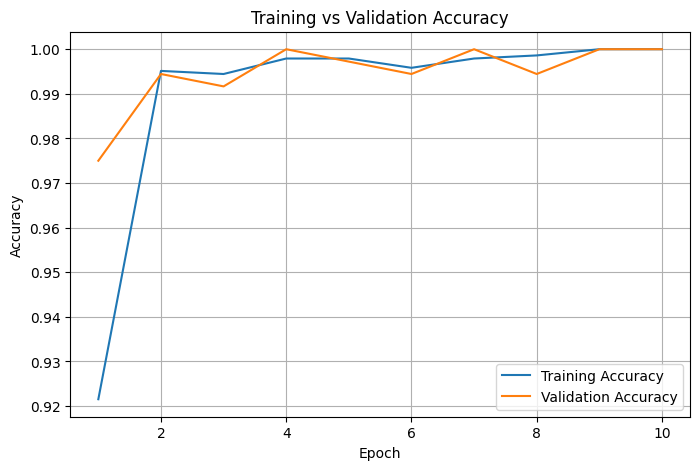

In [20]:
import matplotlib.pyplot as plt

epochs = range(1, NUM_EPOCHS + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    train_accuracies,
    label="Training Accuracy"
)

plt.plot(
    epochs,
    val_accuracies,
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)

plt.show()

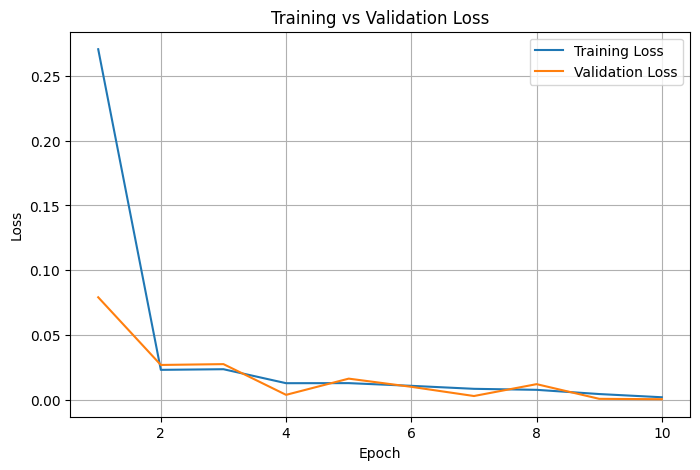

In [21]:
plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    train_losses,
    label="Training Loss"
)

plt.plot(
    epochs,
    val_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

In [22]:
print("=" * 50)
print("FINAL MODEL RESULTS")
print("=" * 50)

print(f"Best Validation Accuracy: {best_val_accuracy * 100:.2f}%")
print(f"Best Model: ResNet-18")
print(f"Number of Classes: {len(train_dataset.classes)}")
print(f"Training Images: {len(train_dataset)}")
print(f"Validation Images: {len(val_dataset)}")

FINAL MODEL RESULTS
Best Validation Accuracy: 100.00%
Best Model: ResNet-18
Number of Classes: 6
Training Images: 1440
Validation Images: 360
